<img src="https://th.bing.com/th/id/R.3cd1c8dc996c5616cf6e65e20b6bf586?rik=09aaLyk4hfbBiQ&riu=http%3a%2f%2fcidics.uanl.mx%2fwp-content%2fuploads%2f2016%2f09%2fcimat.png&ehk=%2b0brgMUkA2BND22ixwLZheQrrOoYLO3o5cMRqsBOrlY%3d&risl=&pid=ImgRaw&r=0" 
     style="float: right; margin-right: 30px;" 
     width="120"
     />

---
 
# **PROCESAMIENTO DEL LENGUAJE NATURAL: TAREA 6: Hierarchical Attention.**
EZAU FARIDH TORRES TORRES.
===
     
<p align="right"> Maestría en Ciencias con Orientación en Matemáticas Aplicadas. </p>
<p align="right"> CENTRO DE INVESTIGACIÓN EN MATEMÁTICAS. </p>
<p align="right"> Fecha de entrega: 11/04/2025. </p>


---

In [1]:
# Necessary libraries.
import numpy as np                             # library for numerical operations.
import matplotlib.pyplot as plt                # library for plotting.
import torch                                   # library for tensor operations.
from nltk.tokenize import TweetTokenizer       # library for tweet tokenization.
from nltk.corpus import stopwords              # library for stopwords.
stopwords_es = set(stopwords.words('spanish')) # set of spanish stopwords.
import os                                      # library for operating system.
import time                                    # library for time.
from typing import Tuple, Callable, List       # library for typing.
import random                                  # library for random numbers.
import pandas as pd                            # library for data manipulation.
from tqdm.notebook import tqdm                 # library for progress bar.
import torch.nn as nn                          # library for neural network operations.
import torch.nn.functional as F                # library for functional operations.
from torch.utils.data import (DataLoader,      # library for data loading.
                              Dataset)         # library for dataset.
from sklearn.metrics import (confusion_matrix,      # library for evaluation.
                             classification_report, # library for evaluation.
                             f1_score)              # library for evaluation.
from torch import optim                        # for neural networks.
from colorama import Fore, Style               # library for colored text.
import seaborn as sns                          # library for data visualization.
sns.set_style("darkgrid")                      # set style for seaborn.
import xml.etree.ElementTree as ET             # library for xml parsing.
np.random.seed(0)                              # seed for reproducibility.
random.seed(0)                                 # seed for reproducibility.
torch.manual_seed(0)                           # seed for reproducibility.
torch.backends.cudnn.benchmark = False         # reproducibility.

# **1.- Intrucciones**

La tarea de Author Profiling la podemos ver como un problema de clasificación supervisada para identificar rasgos demográficos (e.g., genero, edad, nacionalidad, rasgos de personalidad, etc.)  de alguna población objetivo. En esta tarea se proporciona un conjunto de datos de perfiles de usuarios de twitter (solo para español). Cada usuario tiene un conjunto de tweets, además tienes un archivo truth.txt en el que encontrarás las etiquetas objetivo. Para esta tarea solamente las de NACIONALIDAD usaremos. Los datos pertenecen a la tarea aquí: https://pan.webis.de/clef17/pan17-web/author-profiling.html

Con PyTorch haga lo siguiente y ESCRIBA UN MUY BREVE comentario para cada punto.

**IMPORTANTE:** Indique CLARAMENTE en cada parte del Notebook dónde se abordan cada uno de los 7 puntos para su revisión.

Sí necesita crear o leer archivos adicionales, entregará todo en una carpeta GDrive a través de un link compartido en classroom en su entrega, y ADEMAS empaquetado en un Zip como archivo con todos los archivos necesarios para correrlo. No olvide poner su NOMBRE al notebook.

P.D. Puede reusar todo el código que quiera del notebook de atención de la escuela de Luis Fernando Pardo.

# **1.- (10pts) Haga el preprocesamiento que usted considere para limpiar y extraer la información de los documentos.**

> Se crea la función *load_data_and_labels()* la cual carga los datos y sus etiquetas usando la librería *xml*. Con esto se cargan los datos de entrenamiento y validación con sus etiquetas correspondientes, ignorando las partes de género.

In [20]:
def load_data_and_labels(folder_path: str) -> Tuple[List[str], List[Tuple[str, str]]]:
    """
    Load data and labels from the specified folder. 
    
    Parameters
    ----------
    folder_path : str
        Path to the folder containing the XML files and truth.txt file.

    Returns
    -------
    Tuple[List[str], List[Tuple[str, str]]]
        A tuple containing a list of tuples with user IDs and text, 
        and a list of labels corresponding to the user IDs, i.e.
        data = (user_id, text)
    """
    # Load labels from truth.txt
    truth_path = os.path.join(folder_path, 'truth.txt') # Path to the truth file.
    id_to_label = {}                                    # Dictionary to store the labels.

    # Read the truth file and store the labels in a dictionary.
    with open(truth_path, 'r', encoding = 'utf-8') as f: # Open the file.
        for line in f:                                   # Read line by line.
            parts = line.strip().split(':::')            # Split the line.
            user_id, gender, country = parts             # Unpack the parts.
            id_to_label[user_id] = country               # Store the label ignoring gender

    data = []   # List to store the data.
    labels = [] # List to store the labels.

    for filename in os.listdir(folder_path):                # Iterate over the files in the folder.
        if filename.endswith('.xml'):                       # Iterate over the XML files in the folder.
            user_id = filename.replace('.xml', '')          # Extract user ID from filename.
            file_path = os.path.join(folder_path, filename) # Construct the full file path.
            
            # Parse the XML file and extract the text.
            tree = ET.parse(file_path)             
            root = tree.getroot() 
            documents = root.find('documents')

            # Check if the documents element exists.
            for doc in documents.findall('document'):
                text = doc.text
                data.append((user_id, text))          
                labels.append(id_to_label[user_id])  

    return data, labels

# Load data and labels for training and validation sets.
data_train, labels_train = load_data_and_labels(folder_path = 'es_train')
data_val, labels_val = load_data_and_labels(folder_path = 'es_val')

# Number o tweets in training and validation sets.
print(f"Número de tweets en entrenamiento : {len(data_train)}")
print(f"Número de tweets en validación    : {len(data_val)}")
print("")
tweet = 35285
print(f"Tweet de ejemplo : {data_train[tweet][1]}")
print(f"ID de usuario    : {data_train[tweet][0]}")
print(f"Etiqueta         : {labels_train[tweet]}")

Número de tweets en entrenamiento : 335998
Número de tweets en validación    : 84000

Tweet de ejemplo : Me he metido un jatito de esos que te levantas con dolor de cabeza
ID de usuario    : c7b09f7f0ce1f8be78bc8e55faa20742
Etiqueta         : peru


> Convertimos los datos a DataFrames y se grafican para averiguar si se tiene algún desbalance de clases y se obtiene que no.

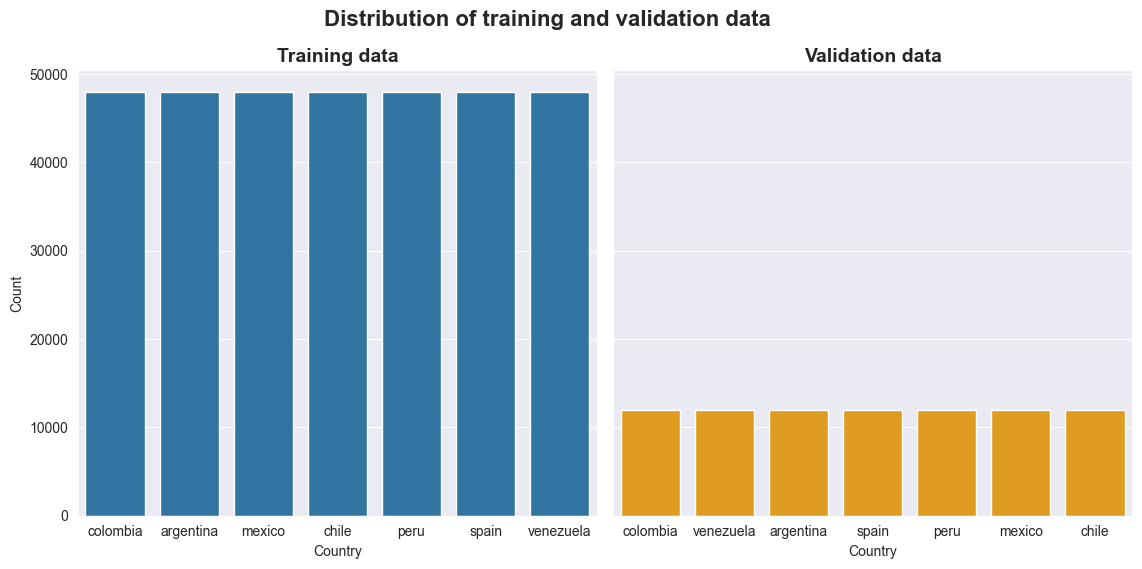

In [21]:
# Create a DataFrame for training and validation data.
df_train = pd.DataFrame(
    labels_train, columns = ["country"], index = range(1, len(labels_train) + 1))
df_val = pd.DataFrame(
    labels_val, columns = ["country"], index = range(1, len(labels_val) + 1))

# Graphs for training and validation data.
fig, axs = plt.subplots(1, 2, figsize = (12,6), sharey = True)
fig.suptitle('Distribution of training and validation data', fontsize = 16, weight = 'bold')

sns.countplot(data = df_train, x = "country", ax = axs[0])                 # Graphs for training data.
sns.countplot(data = df_val, x = "country", ax = axs[1], color = "orange") # Graphs for validation data.

axs[0].set_xlabel("Country")
axs[0].set_ylabel("Count")
axs[0].set_title("Training data", fontsize = 14, weight = 'bold')
axs[1].set_xlabel("Country")
axs[1].set_ylabel("Count")
axs[1].set_title("Validation data", fontsize = 14, weight = 'bold')

plt.tight_layout(rect = [0.04, 0.04, 1, 1])
plt.show()

> Para este problema de clasificación, codificamos las etiquetas por país en un diccionario.

In [23]:
country_map = {country: idx for idx, country in enumerate(df_train["country"].unique())}
print("Country Map:", country_map)

Country Map: {'colombia': 0, 'argentina': 1, 'mexico': 2, 'chile': 3, 'peru': 4, 'spain': 5, 'venezuela': 6}


>Usando la librería *Dataset*, se crea la clase *AuthorProfilingDataset* la cual recibe el corpus en crudo y los labels creados anteriormente y se usa una estructura bastante similar a la usada en el notebook de la escuela. Es opcional eliminar las stopwords y se añaden los diccionarios creados.
>
>- Se define el método estático *load_vocab_embeddings()*, el cual carga el vocabulario y sus vectores de palabras preentrenados desde el archivo 'word2vec_col.txt' y devuelve un diccionario que asigna cada palabra a un índice entero y una matriz donde cada fila es el vector de embeddings correspondiente al índice del vocabulario. Además, se agrega un vector de ceros para representar el padding ('pad') y un vector promedio de todos los embeddings para representar palabras desconocidas ('unk').
>
>- En *preprocessed_text()* se hace un preprocesamiento de los datos, se usa *TweetTokenizer()* en lugar de *word_tokenize()* como tokenizador default.
>
>- Se adaptaron los métodos *\_\_getitem\_\_()* y *collate_fn()* para manejar los labels en formato *('país')* en lugar de {0,1}.

In [ ]:
class AuthorProfilingDataset(Dataset):
    def __init__(self, corpus: List[str], labels: List[str], tokenizer: Callable = None,
                 remove_stopwords: bool = False, stopwords_set: set = stopwords_es,
                 country_map: dict = country_map):
        """
        Initialize the dataset.
        
        Parameters
        ----------
        corpus : list
            List of text data (tweets).
        labels : list
            List of labels
        tokenizer : callable, optional
            Tokenizer for text processing. If None, a default tokenizer is used.
        remove_stopwords : bool, optional
            Whether to remove stopwords. Default is False.
        stopwords_set : set, optional
            Set of stopwords to be removed. Default is Spanish stopwords.
        country_map : dict
            Dictionary that maps labels to their encoding.
        """
        # Initialize the dataset.
        self.corpus = corpus
        self.labels = labels   

        # Label map.
        self.country_map = country_map

        # Load the vocabulary and embeddings.
        self.vocab, self.emb_mat = AuthorProfilingDataset.load_vocab_embeddings()

        # Tokenizer for text processing and additional parameters.
        self.tokenizer = tokenizer if tokenizer else TweetTokenizer(preserve_case = False, reduce_len = True, strip_handles = True)
        self.remove_stopwords = remove_stopwords
        self.stopwords = stopwords_set

        # Initialize the author to tweets and labels.
        self.author_to_tweets = {}
        self.author_to_label = {}

        for (author_id, tweet), label in zip(corpus, labels):
            if author_id not in self.author_to_tweets:
                self.author_to_tweets[author_id] = []
                self.author_to_label[author_id] = label
            self.author_to_tweets[author_id].append(tweet)

        self.author_ids = list(self.author_to_tweets.keys())

    def __len__(self) -> int:
        """
        Return the number of authors in the dataset.
        """
        return len(self.author_ids)

    @staticmethod
    def load_vocab_embeddings() -> Tuple[dict, np.ndarray]:
        """
        Load the vocabulary and pre-trained embeddings. It uses the word2vec model.
        The embeddings are stored in a file called 'word2vec_col.txt'.

        Returns
        -------
        tuple
            A tuple containing the vocabulary and embeddings matrix.
        """
        embeddings_list = []
        vocab = {}
        with open('word2vec_col.txt', 'r') as f:
            for i, line in enumerate(f):
                if i != 0:
                    values = line.split()
                    vocab[values[0]] = i + 1
                    vector = np.asarray(values[1:], dtype = "float32")
                    embeddings_list.append(vector)
        embeddings_list.insert(0, np.mean(np.vstack(embeddings_list), axis = 0)) # Mean vector for unk
        embeddings_list.insert(0, np.zeros(100))                                 # Padding vector
        vocab['pad'] = 0
        vocab['unk'] = 1
        emb_mat = np.vstack(embeddings_list)
        return vocab, emb_mat
    
    def preprocessed_text(self, text: str) -> Tuple[List[str], List[int]]:
        """
        Preprocess the text. 

        Parameters
        ----------
        text : str
            The text to be preprocessed.
        
        Returns
        -------
        tuple
            A tuple containing the list of tokens (words) and their corresponding IDs.
        """
        words = self.tokenizer.tokenize(text.lower())
        if self.remove_stopwords:
            words = [word for word in words if word not in self.stopwords]
        word_ids = [self.vocab[word] if word in self.vocab else self.vocab['unk'] for word in words]

        return words, word_ids
    
    def __getitem__(self, index: int) -> Tuple[List[List[int]], int]:
        """
        Get the item at the specified index.

        Parameters
        ----------
        index : int
            The index of the item to be retrieved.
        
        Returns
        -------
        tuple
            A tuple containing the list of word IDs and the label ID.
        """  
        author_id = self.author_ids[index]        # Get the author ID.
        tweets = self.author_to_tweets[author_id] # Get the tweets for the author.
        label = self.author_to_label[author_id]   # Get the label for the author.
        label_id = self.country_map[label]        # Get the label ID.

        word_ids_list = []
        for tweet in tweets:
            _, word_ids = self.preprocessed_text(tweet)
            word_ids_list.append(word_ids)

        return word_ids_list, label_id
    
    @staticmethod
    def collate_fn(batch, pad_value=0):
        padded_batch = []
        labels = []
    
        # Encuentra los tamaños máximos dinámicamente en el batch
        max_tweets = max(len(tweet_ids_list) for tweet_ids_list, _ in batch)
        max_words = max(len(word_ids) for tweet_ids_list, _ in batch for word_ids in tweet_ids_list)
    
        for tweet_ids_list, label in batch:
            tweet_tensors = []
    
            for word_ids in tweet_ids_list:
                padding = [pad_value] * (max_words - len(word_ids))
                tweet_tensor = torch.tensor(word_ids + padding, dtype=torch.long)
                tweet_tensors.append(tweet_tensor)
    
            while len(tweet_tensors) < max_tweets:
                tweet_tensors.append(torch.zeros(max_words, dtype=torch.long))
    
            tweet_tensor = torch.stack(tweet_tensors)  # [num_tweets, max_words]
            padded_batch.append(tweet_tensor)
            labels.append(label)
    
        padded_input = torch.stack(padded_batch)  # [batch_size, max_tweets, max_words]
        label_tensor = torch.tensor(labels)
    
        return padded_input, label_tensor

> Creamos los datasets y dataloaders usando un tamaño de batch de 128.

In [ ]:
# Create the datasets.
train_dataset = AuthorProfilingDataset(data_train, labels_train, country_map = country_map)
val_dataset = AuthorProfilingDataset(data_val, labels_val, country_map = country_map)

# Create the dataloaders.
batch_size = 16
train_dataloader = DataLoader(train_dataset, batch_size = batch_size, collate_fn = train_dataset.collate_fn, shuffle = True)
val_dataloader = DataLoader(val_dataset, batch_size = batch_size, collate_fn = val_dataset.collate_fn, shuffle = False)

# **2.- (40pts) Diseñe un clasificador con alguna RNN con atención en jerárquia (como en el paper adjunto) que codifique cada perfil de usuario con todos sus tweets y clasifique. El primer nivel intuitivamente recibe embeddings de palabras, el segundo nivel de atención modela los tweets. Preinicialice su red con los embeedings w2v proporcionados.**

> Debido a que sí se hará una comparación de modelos en el punto 7, se comienza definiendo las clases generales:
>
> **1. Trainer:**
>
> En esta clase se describe todo el proceso de entrenamiento para un modelo dado en *nn.Module*. Recibe las épocas a entrenar, los parámetros del optimizador: se eligió *Adam* con parámetros $\beta$ = (0.9, 0.999), regularización $L_2$ vía *weight decay*, y control del learning rate mediante el scheduler *ReduceLROnPlateau* (modo 'min', con patience y factor configurables). El proceso de entrenamiento realiza *early stopping* basado en los puntajes *F1* de la tarea de validación. Se guardan checkpoints automáticos del modelo y del mejor modelo, y permite visualizar las métricas de entrenamiento mediante gráficos.
>
> La función de pérdida utilizada, *nn.CrossEntropyLoss()*, es la elección estándar para tareas de clasificación multiclase, ya que combina softmax con log-loss para penalizar con mayor fuerza las predicciones incorrectas. La elección de *F1-score* como métrica es adecuada por ser un problema multitarea de clasificación, ya que permite balancear precisión y recall. Se emplea *F1-score (macro)* ya que se tienen clases balanceadas.
>
> **2. Evaluation:**
>
> Se usa para evaluar los modelos de clasificación entrenados. Se calculan métricas de desempeño como pérdida promedio y puntaje *F1* tanto en los conjuntos de entrenamiento como validación, se generan reportes por clase usando *classification_report*, y se visualizan los resultados mediante matrices de confusión; la clase asume que el modelo implementado por el Trainer devuelve logits y que la evaluación se hace por medio del método *eval_model*, reutilizando la lógica de entrenamiento y evaluación configurada.

In [ ]:
class Trainer:
    def __init__(
            self, model: nn.Module, epochs: int, train_dataset: Dataset, train_dataloader: DataLoader,
            val_dataloader: DataLoader, device: str, lr: float = 1e-3, patience: int = 5,
            weight_decay: float = 1e-4, betas: Tuple[float, float] = (0.9, 0.999),
            lr_patience: int = 3, lr_factor: float = 0.1, checkpoint_path: str = 'trained_model',
            checkpoint_filename: str = 'checkpoint.pth', best_model_filename: str = 'best_model.pth'
    ):
        """
        Initialize the Trainer class.
        
        Parameters
        ----------
        model : nn.Module
            The model to be trained.
        epochs : int
            Number of epochs for training.
        train_dataset : Dataset
            The training dataset.
        train_dataloader : DataLoader
            DataLoader for the training dataset.
        val_dataloader : DataLoader
            DataLoader for the validation dataset.
        device : str
            The device to be used for training (CPU or GPU).
        lr : float, optional
            Learning rate for the optimizer. Default is 1e-3.
        patience : int, optional
            Number of epochs with no improvement after which training will be stopped. Default is 5.
        weight_decay : float, optional
            Weight decay for the optimizer. Default is 1e-4.
        betas : tuple, optional
            Betas for the optimizer. Default is (0.9, 0.999).
        lr_patience : int, optional
            Number of epochs with no improvement after which learning rate will be reduced. Default is 3.
        lr_factor : float, optional
            Factor by which the learning rate will be reduced. Default is 0.1.
        checkpoint_path : str, optional
            Path to save the checkpoint. Default is 'trained_model'.
        checkpoint_filename : str, optional
            Filename for the checkpoint. Default is 'checkpoint.pth'.
        best_model_filename : str, optional
            Filename for the best model. Default is 'best_model.pth'.
        """
        # Initialize the trainer.
        self.model = model.to(device)
        self.epochs = epochs
        self.train_dataset = train_dataset
        self.train_dataloader = train_dataloader
        self.val_dataloader = val_dataloader
        self.device = device
        self.patience = patience

        # Checkpoint parameters.
        self.checkpoint_path     = checkpoint_path
        self.checkpoint_filename = checkpoint_filename
        self.best_model_filename = best_model_filename

        # Training metadata.
        self.train_loss_history = []   # Training loss history.
        self.val_loss_history   = []   # Validation loss history.
        self.f1_history         = []   # f1 metric history for country.
        self.best_val_f1        = 0    # Best f1 metric in validation set.
        self.n_no_improvement   = 0    # Number of epochs without improvement.
        self.best_state_dict    = None # Store the best model state dict.

        # Optimizer.
        self.optimizer   = optim.Adam(           
            params       = model.parameters(), # parameters to optimize.
            lr           = lr,                 # learning rate.
            weight_decay = weight_decay,       # weight decay.
            betas        = betas               # betas for the optimizer.
        )

        # Scheduler.
        self.scheduler = optim.lr_scheduler.ReduceLROnPlateau( 
            optimizer  = self.optimizer, # optimizer to adjust.
            mode       = 'min',          # mode (min means reduce when the quantity monitored has stopped decreasing).
            patience   = lr_patience,    # patience (number of epochs with no improvement after which learning rate will be reduced).
            factor     = lr_factor       # factor by which the learning rate will be reduced. new_lr = lr * factor.
        )

        # Loss function for classification.
        self.criterion = nn.CrossEntropyLoss()

    def eval_model(self, dataloader: DataLoader) -> dict:
        """
        Evaluates the multitask model.

        Parameters
        ----------
        dataloader : DataLoader
            DataLoader for the evaluation dataset.

        Returns
        -------
        tuple
            A tuple containing:
            - average loss,
            - F1 score,
            - scores,
            - predictions,
            - real labels.
        """
        with torch.no_grad():
            self.model.eval() # Set the model to evaluation mode.
            
            losses = []                         # List to store the losses.
            preds, targets, scores = [], [], [] # List to store the predictions, targets and scores for country.
            words_list = []                     # List to store the words.
    
            # Iterate over the batches.
            for inputs, labels in tqdm(dataloader, desc = 'Evaluation...', colour = 'deepskyblue'):
                torch.cuda.empty_cache() # Clear the cache.
                inputs, labels = inputs.to(self.device), labels.to(self.device)
    
                # Forward pass.
                logits = self.model(inputs) # Output of the model.

                # Calculate the loss for the batch.
                loss_per_batch = self.criterion(logits, labels)
                losses.append(loss_per_batch.item())

                # Predictions and targets.
                pred = logits.argmax(dim = 1) # Predicted class for country

                # Append predictions and true labels to the lists.
                preds += pred.cpu().tolist()

                targets += labels.cpu().tolist()

                # Probabilities using softmax (for score/confidence tracking)
                probs = torch.softmax(logits, dim = 1)
                scores += probs[torch.arange(len(pred)), pred].cpu().tolist()

            # F1 scores
            f1 = f1_score(targets, preds, average = 'macro')

            return {
                'loss'    : np.mean(losses),
                'f1'      : f1,
                'scores'  : scores,
                'preds'   : preds,
                'targets' : targets,
                }

    def train(self):
        """
        Train the model.
        """
        start_time = time.time() # Start time of the training.

        for epoch in range(1, self.epochs + 1):
            self.model.train()
            loss_train = 0
            epoch_time = time.time() # Start time of the epoch.
    
            for inputs, labels in tqdm(self.train_dataloader, desc = 'Training...', colour = 'green'):
                torch.cuda.empty_cache()   # Clear the cache.
                self.optimizer.zero_grad() # Zero the gradients.
    
                inputs, labels = inputs.to(self.device), labels.to(self.device)
    
                logits = self.model(inputs) # Forward pass.
    
                # Calculate the loss for the batch.
                loss_per_batch = self.criterion(logits, labels)
    
                # Backward pass and optimization.
                loss_per_batch.backward()
                self.optimizer.step()
                loss_train += loss_per_batch.item()
    
            # Average loss for the epoch.
            loss_train /= len(self.train_dataloader)
    
            # Evaluate the model on the validation set.
            val_results = self.eval_model(self.val_dataloader)
            val_loss    = val_results['loss']
            val_f1      = val_results['f1']

            # Store the results.
            self.train_loss_history.append(loss_train)
            self.val_loss_history.append(val_loss)
            self.f1_history.append(val_f1)
    
            # Sum of F1 scores to determine the best model.
            is_improvement = val_f1 > self.best_val_f1
            
            if is_improvement:
                self.best_val_f1 = val_f1
                self.best_time = time.time() - start_time
                self.best_epoch = epoch
                self.n_no_improvement = 0
            else:
                self.n_no_improvement += 1

            # Save checkpoint.
            elapsed_time = time.time() - start_time # Elapsed time since the start of training.
            self.save_checkpoint(
                state = {
                    # This epoch information.
                    'epoch'              : epoch,
                    'state_dict'         : self.model.state_dict(),
                    'loss_train'         : loss_train,
                    'loss_val'           : val_loss,
                    'elapsed_time'       : elapsed_time,
                    # Best information.
                    'best_val_f1'        : self.best_val_f1,
                    'best_epoch'         : self.best_epoch,
                    'best_time'          : self.best_time,
                    # History information.
                    'train_loss_history' : self.train_loss_history,
                    'val_loss_history'   : self.val_loss_history,
                    'f1_history'         : self.f1_history,
                },
                is_best = is_improvement
            )

            # Early stopping.
            if self.n_no_improvement >= self.patience:
                tqdm.write(f"{Fore.RED}Early stopping triggered at epoch {epoch}!{Style.RESET_ALL}")
                break
            elif loss_train < 1e-5:
                tqdm.write(f"{Fore.RED}Loss is too low, stopping training!{Style.RESET_ALL}")
                break
    
            # Print the results.
            tqdm.write(f"{Style.BRIGHT}{Fore.CYAN} Epoch{epoch:>2}/{self.epochs}{Style.RESET_ALL}"
                       f"  ➤ Training loss: {Fore.GREEN}{loss_train:.4f}{Style.RESET_ALL} | "
                       f"Validation Loss: {Fore.YELLOW}{val_loss:.4f}{Style.RESET_ALL} | "
                       f"F1: {Fore.MAGENTA}{val_f1:.4f}{Style.RESET_ALL} | "
                       f"Epoch Time: {time.time() - epoch_time:.2f} s | "
                       f"Total Time: {elapsed_time:.2f} s")
            
        print(f"\n{Style.BRIGHT}--- Total Training Time: {elapsed_time:.2f} seconds ---{Style.RESET_ALL}")

    def save_checkpoint(self, state: dict, is_best: bool) -> None:
        """
        Save a checkpoint of the model, including the state dictionary, training metadata,
        optimizer state, and the initialization parameters used to construct the model.

        Parameters
        ----------
        state : dict
            Dictionary with the model state, best model state, loss histories, and optimizer state.
        is_best : bool
            If True, also save the model as the best checkpoint.
        """
        if not os.path.exists(self.checkpoint_path):
            os.makedirs(self.checkpoint_path, exist_ok = True)

        if is_best:
            state['best_model_state_dict'] = self.model.state_dict()

        filepath = os.path.join(self.checkpoint_path, self.checkpoint_filename)
        torch.save(state, filepath)

        if is_best:
            best_path = os.path.join(self.checkpoint_path, self.best_model_filename)
            torch.save({'best_model_state_dict': self.model.state_dict()}, best_path)

    def plot_metrics(self):
        epochs = list(range(1, len(self.train_loss_history) + 1))
    
        fig, axes = plt.subplots(1, 2, figsize = (16,6)) 
    
        # Loss plot.
        axes[0].plot(epochs, self.train_loss_history, label = 'Training Loss', color = '#1f77b4')
        axes[0].plot(epochs, self.val_loss_history, label = 'Validation Loss', color = '#ff7f0e')
        axes[0].axvline(self.best_epoch, linestyle = "--", color = "gray", alpha = 0.7, label = f"Best Epoch: {self.best_epoch}")
        axes[0].set_title('Loss over Epochs', fontsize = 14, fontweight = 'bold')
        axes[0].set_xlabel('Epochs', fontsize = 12)
        axes[0].set_ylabel('Loss', fontsize = 12)
        axes[0].legend(fontsize = 12)
        axes[0].grid()
    
        # F1 Score plot.
        axes[1].plot(epochs, self.f1_history, label = 'F1', color = '#d62728')
        axes[1].axvline(self.best_epoch, linestyle = "--", color = "gray", alpha = 0.7, label = f"Best Epoch: {self.best_epoch}")
        axes[1].set_title('F1 Score over Epochs', fontsize = 14, fontweight = 'bold')
        axes[1].set_xlabel('Epochs', fontsize = 12)
        axes[1].set_ylabel('F1 Score', fontsize = 12)
        axes[1].legend(fontsize = 12)
        axes[1].grid()
    
        plt.tight_layout()
        plt.show()

In [ ]:
class Evaluation:
    @staticmethod
    def plot_confusion_matrix(y_true: List[int], y_pred: List[int], labels: List[str]) -> None:
        """
        Display side-by-side confusion matrices for gender and country classification.

        Parameters
        ----------
        y_true : list or array
            True country labels.
        y_pred : list or array
            Predicted country labels.
        labels : list of str
            Class names for country.
        """
        fig, ax = plt.subplots(figsize = (8, 6))
        cm = confusion_matrix(y_true, y_pred)
        sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Purples',
                    xticklabels = labels, yticklabels = labels, ax = ax)
        ax.set_title("Confusion Matrix", fontsize = 16, fontweight = 'bold')
        ax.set_xlabel("Predicted Label", fontsize = 12)
        ax.set_ylabel("True Label", fontsize = 12)

        plt.tight_layout()
        plt.show()

    @staticmethod
    def evaluate_best_model(trainer: Trainer, train_dataloader: DataLoader, val_dataloader: DataLoader,
                            filename: str = "trained_model/best_model.pth") -> Tuple[dict, dict]:
        """
        Evaluate the best trainer on the training and validation sets.

        Parameters
        ----------
        train_dataloader : DataLoader
            DataLoader for the training set.
        val_dataloader : DataLoader
            DataLoader for the validation set.
        results : bool, optional
            Whether to return the results. Default is True.
        
        Returns
        -------
        tuple
            A tuple containing the evaluation results for the training and validation sets.
        """
        checkpoint = torch.load(filename, map_location = 'cpu', weights_only = True)
        trainer.model.load_state_dict(checkpoint['best_model_state_dict'])      
        trainer.model.eval() # Set the trainer to evaluation mode.
        
        print("\nEvaluando en conjunto de entrenamiento:")
        train_results = trainer.eval_model(train_dataloader)
        train_loss    = train_results['loss']
        f1_train      = train_results['f1']

        print("\nEvaluando en conjunto de validación:")
        val_results = trainer.eval_model(val_dataloader)
        val_loss    = val_results['loss']
        f1_val      = val_results['f1']

        print(f"\nTrain Loss : {train_loss:.4f} | F1 : {f1_train:.4f}")
        print(f"Val Loss   : {val_loss:.4f} | F1 : {f1_val:.4f}")

        # Labels for the results.
        labels = [label for label, idx in sorted(trainer.train_dataset.country_map.items(), key = lambda x: x[1])]

        print("\nPer-class report:")
        print(classification_report(val_results['targets'], val_results['preds'], target_names = labels))

        # Plot the confusion matrices
        Evaluation.plot_confusion_matrix(
            val_results['targets'], val_results['preds'], labels
        )

        return train_results, val_results

# Model

In [ ]:
class Attention(nn.Module):
    def __init__(self, hidden_size):
        super(Attention, self).__init__()
        self.hidden_size = hidden_size
        self.linear = nn.Linear(hidden_size, hidden_size)
        self.context_vector = nn.Parameter(torch.randn(hidden_size))

    def forward(self, encoder_outputs):
        # encoder_outputs: [batch, seq_len, hidden_size]
        u = torch.tanh(self.linear(encoder_outputs))  # [batch, seq_len, hidden_size]
        attn_weights = torch.matmul(u, self.context_vector)  # [batch, seq_len]
        attn_weights = F.softmax(attn_weights, dim=1)  # [batch, seq_len]
        weighted_output = torch.sum(encoder_outputs * attn_weights.unsqueeze(-1), dim=1)  # [batch, hidden_size]
        return weighted_output, attn_weights

class HierarchicalAttentionNetwork(nn.Module):
    def __init__(self, vocab_size, emb_dim, word_hidden_size, tweet_hidden_size, num_classes, emb_matrix):
        super().__init__()
        self.embedding = nn.Embedding.from_pretrained(torch.tensor(emb_matrix, dtype=torch.float32), freeze=False)

        self.word_gru = nn.GRU(emb_dim, word_hidden_size, batch_first=True, bidirectional=True)
        self.word_attention = nn.Linear(2 * word_hidden_size, 1)

        self.tweet_gru = nn.GRU(2 * word_hidden_size, tweet_hidden_size, batch_first=True, bidirectional=True)
        self.tweet_attention = nn.Linear(2 * tweet_hidden_size, 1)

        self.classifier = nn.Linear(2 * tweet_hidden_size, num_classes)

    def forward(self, x):
        # x: [batch_size, max_tweets, max_words]
        batch_size, num_tweets, num_words = x.size()

        x = x.view(-1, num_words)                       # [batch_size * max_tweets, max_words]
        x = self.embedding(x)                           # [batch_size * max_tweets, max_words, emb_dim]

        word_output, _ = self.word_gru(x)               # [B*T, W, 2*H]
        word_attn_weights = torch.softmax(self.word_attention(word_output).squeeze(-1), dim=1)  # [B*T, W]
        tweet_representations = torch.sum(word_output * word_attn_weights.unsqueeze(-1), dim=1)  # [B*T, 2H]
        tweet_representations = tweet_representations.view(batch_size, num_tweets, -1)           # [B, T, 2H]

        tweet_output, _ = self.tweet_gru(tweet_representations)              # [B, T, 2H']
        tweet_attn_weights = torch.softmax(self.tweet_attention(tweet_output).squeeze(-1), dim=1)  # [B, T]
        doc_representation = torch.sum(tweet_output * tweet_attn_weights.unsqueeze(-1), dim=1)     # [B, 2H']

        return self.classifier(doc_representation)


In [ ]:
# Dispositivo
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Parámetros para HAN
params_HAN = {
    'vocab_size'       : len(train_dataset.emb_mat),
    'emb_dim'          : 100,
    'word_hidden_size' : 50,
    'tweet_hidden_size': 50,
    'num_classes'      : len(country_map),
    'emb_matrix'       : train_dataset.emb_mat
}

params_train_HAN = {
    'epochs'              : 5,
    'train_dataset'       : train_dataset,
    'train_dataloader'    : train_dataloader,  # Usa el que tenga collate_fn jerárquico
    'val_dataloader'      : val_dataloader,
    'device'              : device,
    'lr'                  : 1e-3,
    'patience'            : 5,
    'weight_decay'        : 1e-4,
    'betas'               : (0., 0.999),
    'lr_patience'         : 3,
    'lr_factor'           : 0.1,
    'checkpoint_filename' : 'HAN_checkpoint.pth',
    'best_model_filename' : 'best_HAN_model.pth'
}

In [ ]:
# Crear modelo
model_HAN = HierarchicalAttentionNetwork(**params_HAN).to(device)

# Crear trainer
trainer_HAN = Trainer(model = model_HAN, **params_train_HAN)

# Entrenar
trainer_HAN.train()

In [ ]:
train_results_RNN, val_results_RNN = Evaluation.evaluate_best_model(trainer_HAN, train_dataloader, val_dataloader,
                                                                    filename = "trained_model/best_HAN_model.pth")

trainer_HAN.plot_metrics()

# **5.- (30pts) Discuta brevemente el rendimiento del modelo anterior. Para el punto anterior, construya algunas visualizaciones como en la Figura 6 del paper de atención jerárquica y discuta.**

# **6.- (20pts) Conteste lo siguiente MUY brevemente:**

### **6.1.- ¿Qué representación de términos uso el profesor para participar? http://ceur-ws.org/Vol-1866/paper_109.pdf**

### **6.2.- ¿Qué usó el primer lugar de la competencia? (Basile, et al.) (Consulte: http://ceur-ws.org/Vol-1866/)**

### **6.3.- ¿Cuántos y que competidores usaron deep learning? En una o dos oraciones escriba qué hicieron: https://ceur-ws.org/Vol-1866/**

# **7.- (10pts) extra (Máxima Calificación 110%) para esta tarea: haga una comparación que muestre si la atención en jerarquía es util vs no tenerla (e.g., sin atención o tener un solo nivel de atención)**